# **Human-Guided Agentic AI Workflows for Enterprise Operational Decision-Making**



## Import Libraries

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load Dataset

In [152]:
agentic_ai_data= pd.read_csv("AgenticAI_Leadership_Dataset_v1.csv")

print(agentic_ai_data.head())

   Record_ID            Industry Organization_Size Leadership_Function  \
0  AAI-00001           Education             Small          Operations   
1  AAI-00002       Manufacturing             Small          Operations   
2  AAI-00003  Telecommunications            Medium          Operations   
3  AAI-00004              Energy             Large     Human Resources   
4  AAI-00005  Financial Services             Small           Marketing   

  AI_Maturity_Level                  Agent_Type            Use_Case_Area  \
0             Early       Risk Monitoring Agent       Process Automation   
1          Advanced  Knowledge Management Agent       Demand Forecasting   
2           Leading   Workflow Automation Agent       Process Automation   
3           Leading   Workflow Automation Agent       Workforce Planning   
4          Advanced           Procurement Agent  Content Personalization   

  Agent_Autonomy_Level Decision_Making_Type  Context_Awareness_Score  \
0                  Low    

## Basic Data Information

In [153]:
print("Shape:", agentic_ai_data.shape)

Shape: (5500, 20)


In [154]:
print("\nInfo:")
print(agentic_ai_data.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Record_ID                         5500 non-null   object 
 1   Industry                          5500 non-null   object 
 2   Organization_Size                 5500 non-null   object 
 3   Leadership_Function               5500 non-null   object 
 4   AI_Maturity_Level                 5500 non-null   object 
 5   Agent_Type                        5500 non-null   object 
 6   Use_Case_Area                     5500 non-null   object 
 7   Agent_Autonomy_Level              5500 non-null   object 
 8   Decision_Making_Type              5500 non-null   object 
 9   Context_Awareness_Score           5500 non-null   float64
 10  Task_Complexity_Level             5500 non-null   object 
 11  Human_Oversight_Level             5500 non-null   object 
 12 

In [155]:
print("\nStatistical Summary:")
print(agentic_ai_data.describe())


Statistical Summary:
       Context_Awareness_Score  Task_Success_Rate  Response_Time_Seconds  \
count              5500.000000        5500.000000            5500.000000   
mean                 54.123473          73.737655               7.490287   
std                  15.654109          10.201866               2.589438   
min                  20.000000          42.000000               1.200000   
25%                  42.700000          66.800000               5.610000   
50%                  54.750000          74.000000               7.320000   
75%                  65.725000          81.000000               9.240000   
max                  97.500000          98.000000              16.020000   

       Productivity_Improvement_Percent  Leadership_Trust_Score  
count                       5500.000000             5500.000000  
mean                          12.748782               62.254109  
std                            5.794155               13.730996  
min                          

In [156]:
print("\nMissing Values:")
print(agentic_ai_data.isnull().sum())


Missing Values:
Record_ID                           0
Industry                            0
Organization_Size                   0
Leadership_Function                 0
AI_Maturity_Level                   0
Agent_Type                          0
Use_Case_Area                       0
Agent_Autonomy_Level                0
Decision_Making_Type                0
Context_Awareness_Score             0
Task_Complexity_Level               0
Human_Oversight_Level               0
Explainability_Level                0
Data_Privacy_Compliance             0
Integration_Level                   0
Task_Success_Rate                   0
Response_Time_Seconds               0
Productivity_Improvement_Percent    0
Leadership_Trust_Score              0
Adoption_Success_Level              0
dtype: int64


## Data Preprocessing

In [157]:
df = agentic_ai_data
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_4663/2388603235.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_4663/2388603235.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [158]:
# Encode categorical variables
le = LabelEncoder()

for col in agentic_ai_data.select_dtypes(include="object").columns:
    agentic_ai_data[col] = le.fit_transform(agentic_ai_data[col])

print(df.head())

   Record_ID  Industry  Organization_Size  Leadership_Function  \
0          0         0                  3                    6   
1          1         6                  3                    6   
2          2        10                  2                    6   
3          3         1                  1                    3   
4          4         2                  3                    5   

   AI_Maturity_Level  Agent_Type  Use_Case_Area  Agent_Autonomy_Level  \
0                  2           6             22                     1   
1                  0           4              6                     2   
2                  3           9             22                     0   
3                  3           9             33                     2   
4                  0           5              3                     2   

   Decision_Making_Type  Context_Awareness_Score  Task_Complexity_Level  \
0                     2                     24.0                      2   
1             

## Data Visualization

In [159]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11


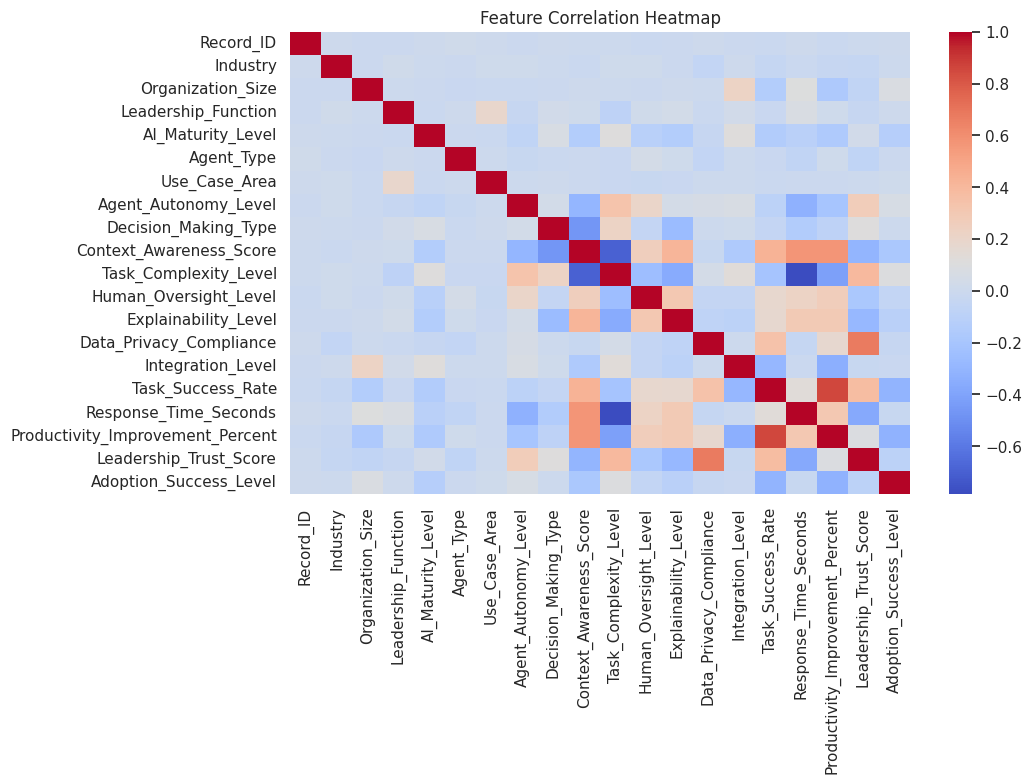

In [160]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

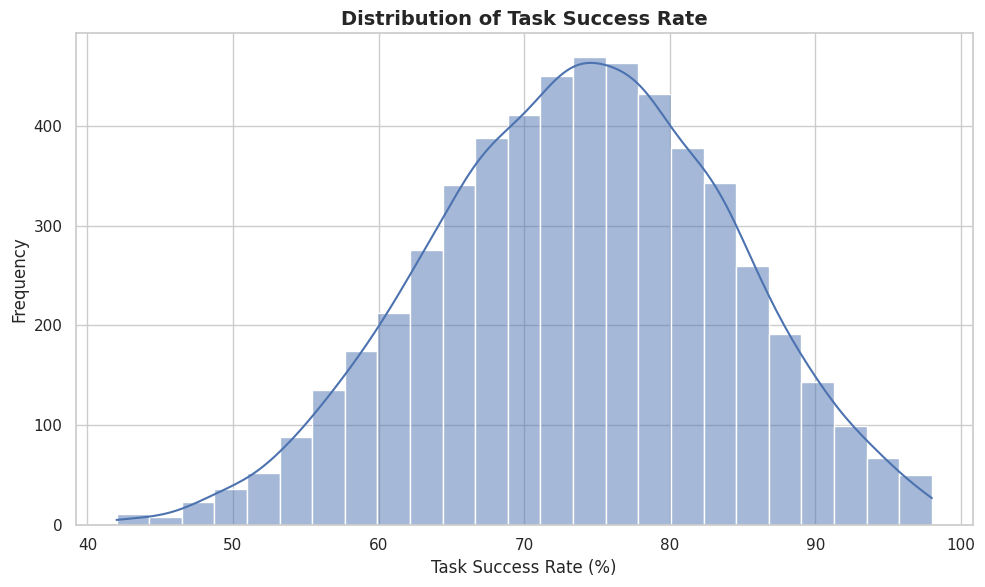

In [161]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Task_Success_Rate",
    bins=25,
    kde=True
)

plt.title("Distribution of Task Success Rate", fontsize=14, fontweight="bold")
plt.xlabel("Task Success Rate (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

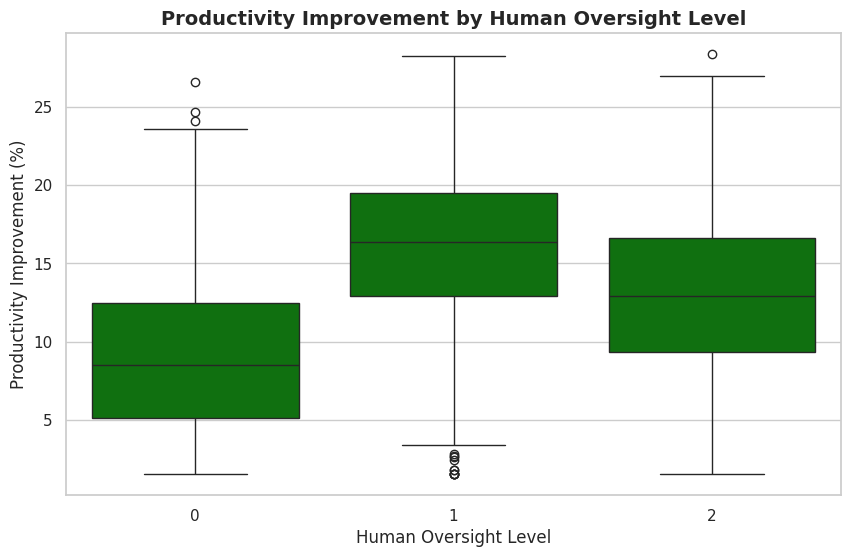

In [180]:

sns.boxplot(
    data=df,
    x="Human_Oversight_Level",
    y="Productivity_Improvement_Percent",
    color="green"
)

plt.title("Productivity Improvement by Human Oversight Level", fontsize=14, fontweight="bold")
plt.xlabel("Human Oversight Level")
plt.ylabel("Productivity Improvement (%)")
plt.show()

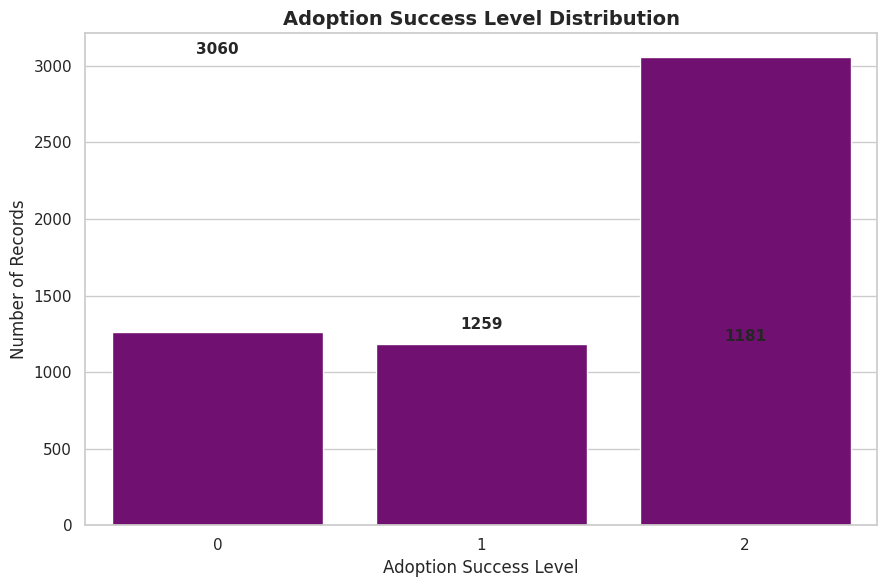

In [179]:
adoption_counts = df["Adoption_Success_Level"].value_counts().reset_index()
adoption_counts.columns = ["Adoption_Success_Level", "Count"]

plt.figure(figsize=(9, 6))

sns.barplot(
    data=adoption_counts,
    x="Adoption_Success_Level",
    y="Count",
    color="purple"
)

plt.title("Adoption Success Level Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Adoption Success Level")
plt.ylabel("Number of Records")
for index, value in enumerate(adoption_counts["Count"]):
    plt.text(index, value + 20, str(value), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

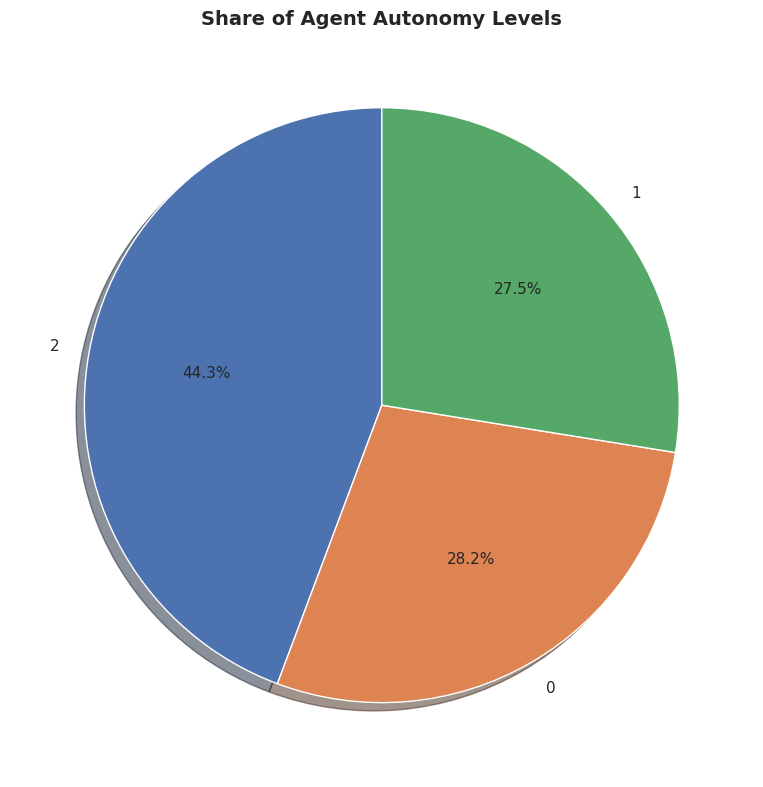

In [164]:
autonomy_counts = agentic_ai_data["Agent_Autonomy_Level"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    autonomy_counts,
    labels=autonomy_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

plt.title("Share of Agent Autonomy Levels", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Feature Selection

In [165]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [167]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## MODEL 1 — Logistic Regression

In [168]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [169]:
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8081818181818182
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       274
           1       0.80      0.76      0.78       231
           2       0.81      0.86      0.83       595

    accuracy                           0.81      1100
   macro avg       0.81      0.79      0.80      1100
weighted avg       0.81      0.81      0.81      1100



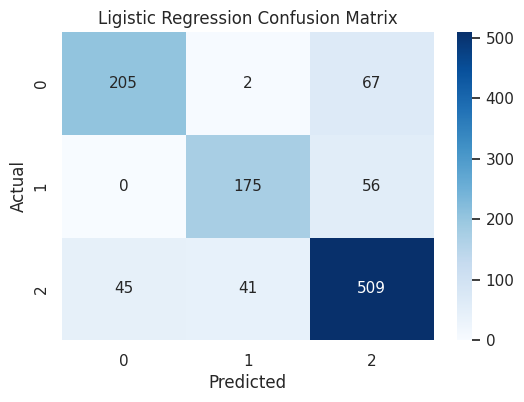

In [181]:
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Ligistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## MODEL 2 — Random Forest Classifier

In [171]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [172]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8518181818181818
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       274
           1       0.88      0.82      0.85       231
           2       0.85      0.89      0.87       595

    accuracy                           0.85      1100
   macro avg       0.86      0.84      0.85      1100
weighted avg       0.85      0.85      0.85      1100



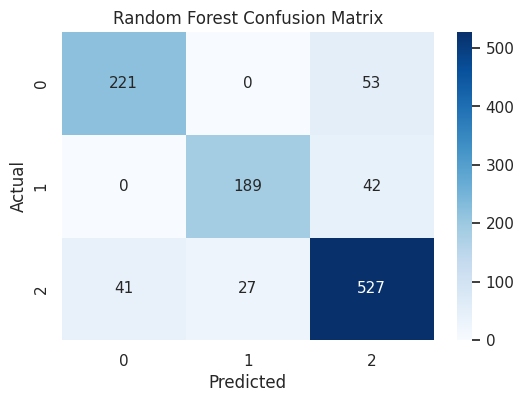

In [173]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Comparison

In [174]:
models = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(models)

                 Model  Accuracy
0  Logistic Regression  0.808182
1        Random Forest  0.851818
